# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [1]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_raw_macro.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="timepoint" # stream2 or timepoint

In [2]:
import sys
#!pip install gseapy
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import gseapy as gp
from gseapy import get_library
from scipy.stats import fisher_exact
import json
from scipy.signal import argrelmin
from scipy.stats import gaussian_kde
#! pip install goatools
#!pip install leidenalg

In [3]:
warnings.filterwarnings("ignore")
adata = sc.read(input_file) # read data 
if adata.X.max() > 10 : # check if is raw data, need to be > 10
    # Normalization
    sc.pp.normalize_total(adata) # 
    sc.pp.log1p(adata)
    print("=== This dataset is now normalised")
else :
    print("=== This dataset appears to have already been normalised")

# Verify if we have only the cells expected and the macrostates 
print("=== Cell type and macrostates in our dataset")
print(adata.obs["Annotation"].unique())
print(adata.obs["macrostates"].unique())

=== This dataset is now normalised
=== Cell type and macrostates in our dataset
['B intermediate' 'B naive' 'B' 'B memory' 'Bridge']
['I2' 'None' 'I1' 'T1' 'T3' 'T2']


# Definition of the majority vote


Processing I1...
  5018 cells
 2359 genes after DEG
DataFrame created with 2359 genes DEG
 2356 genes after removing all-zero
  scBoolSeq fitted

Processing I2...
  1015 cells
 1266 genes after DEG
DataFrame created with 1266 genes DEG
 1262 genes after removing all-zero
  scBoolSeq fitted

Processing T1...
  264 cells
 3343 genes after DEG
DataFrame created with 3343 genes DEG
 3343 genes after removing all-zero
  scBoolSeq fitted

Processing T2...
  1797 cells
 2859 genes after DEG
DataFrame created with 2859 genes DEG
 2859 genes after removing all-zero
  scBoolSeq fitted

Processing T3...
  1699 cells
 3174 genes after DEG
DataFrame created with 3174 genes DEG
 3174 genes after removing all-zero
  scBoolSeq fitted


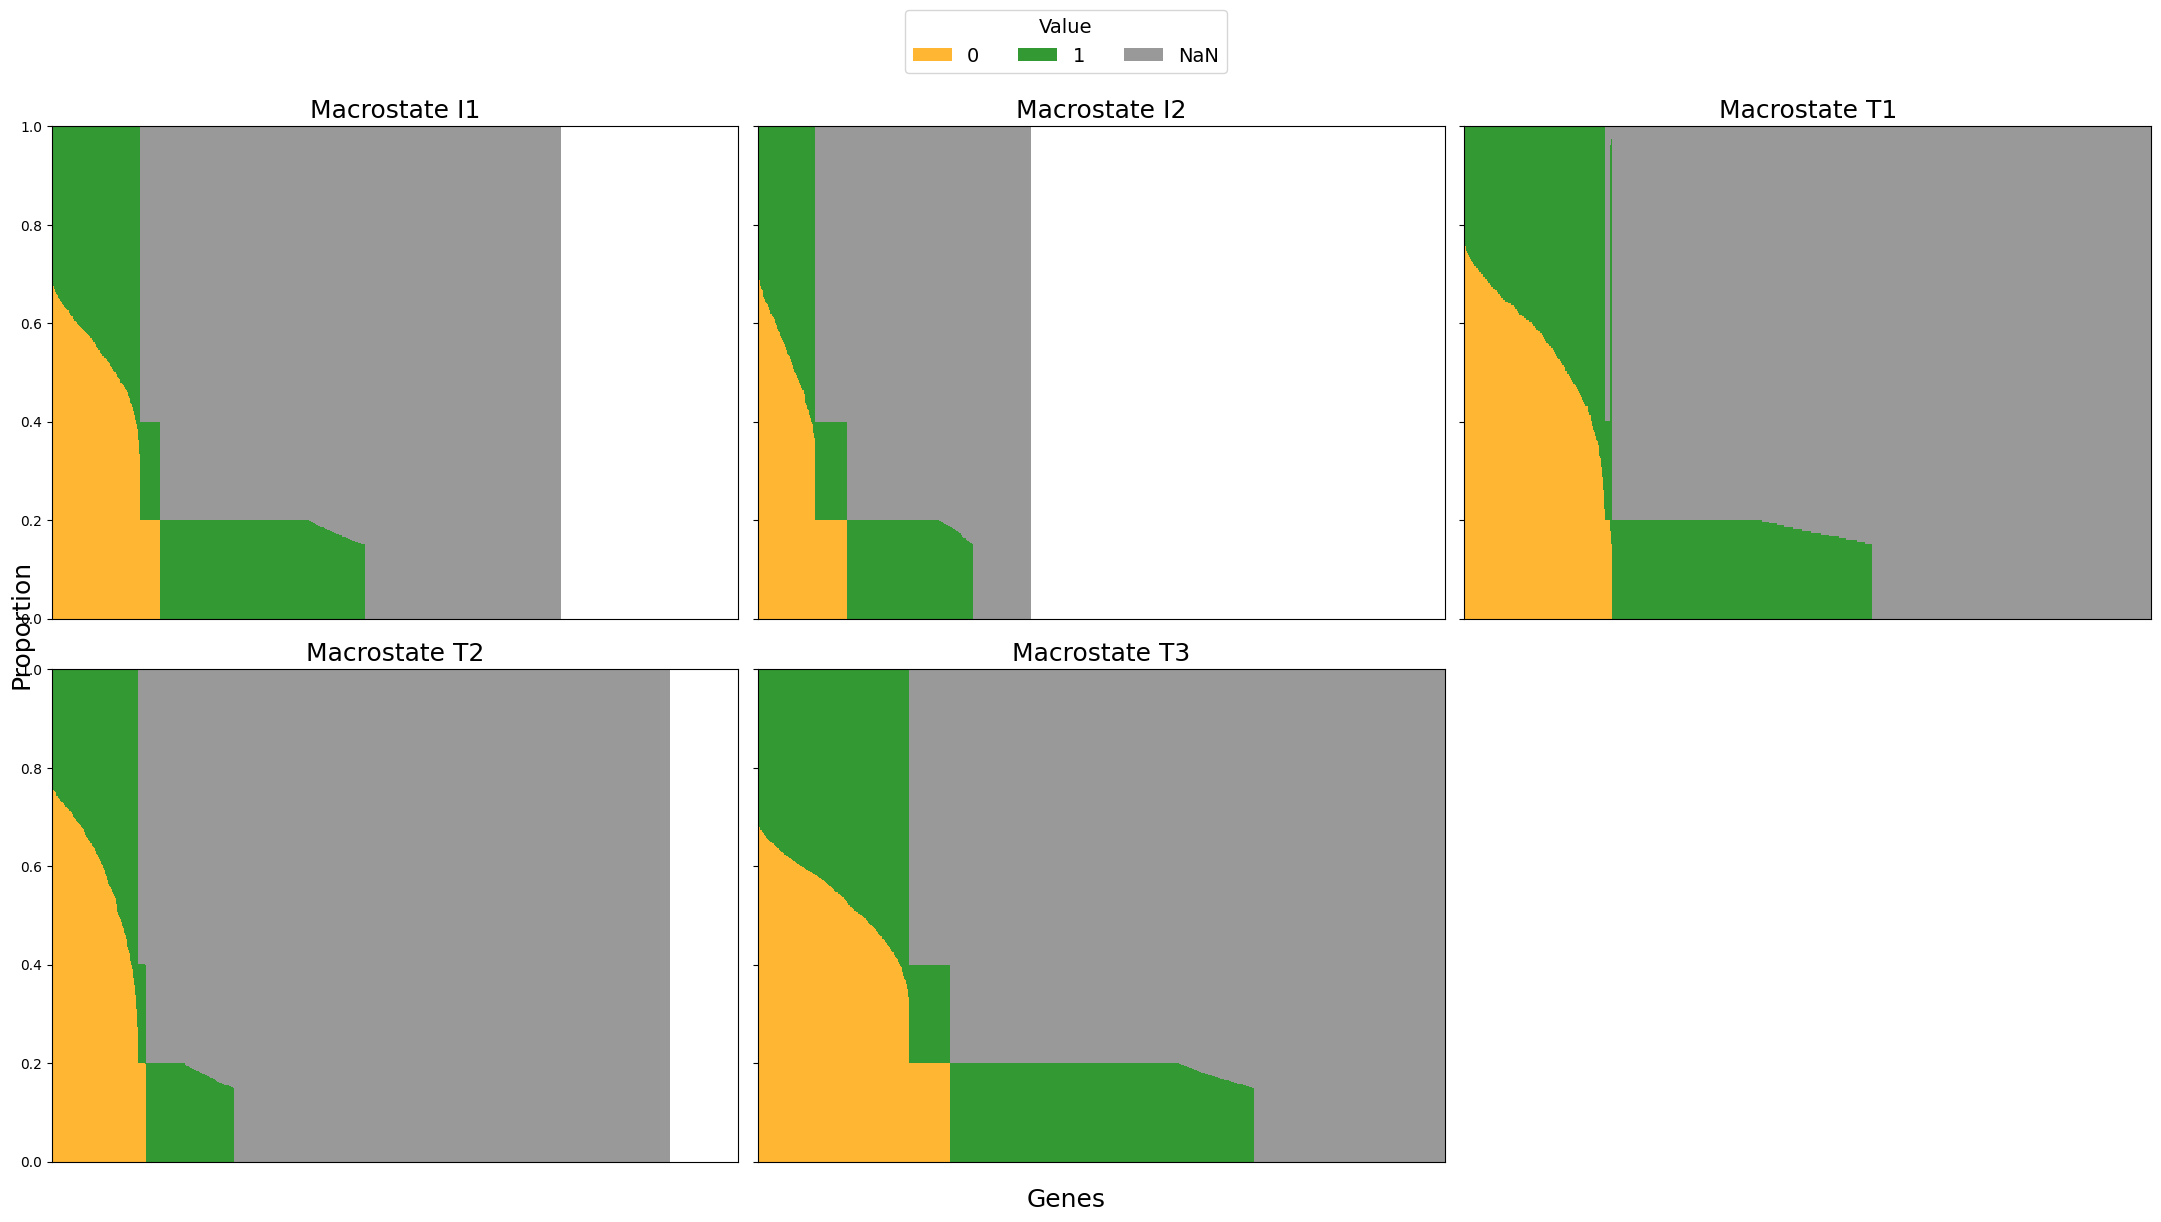

In [6]:
warnings.filterwarnings("ignore")
# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()

macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']

binarized_states = {}
adata_ct_dict = {}
deg_lists_up = {}
deg_lists_down = {}
enrich_results = {}

# One figure 
fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ct in enumerate(macrostates):
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")

    ax = axes[i]

    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : Differential Gene Expression to keep the main genes variable between macrostates 
    sc.tl.rank_genes_groups(adata_no_none, groupby="macrostates", groups=[ct], reference="rest", method="wilcoxon",use_raw=False)
    df = sc.get.rank_genes_groups_df(adata_no_none, group=ct)
    # keep the significant genes and with high variation log(FC) > 0.5 ou <-0.5
    df_sig = df[(df["pvals_adj"] < 0.05)&((df["logfoldchanges"] > 0.5) |(df["logfoldchanges"] < -0.5))]  
    df_up = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] > 0.5)]
    df_down = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] < -0.5)]

    deg_lists_up[ct] = df_up["names"].tolist()
    deg_lists_down[ct] = df_down["names"].tolist()  
    n_genes = df_sig.shape[0]
    genes_to_keep = df_sig['names'].tolist()
        
    print(f" {n_genes} genes after DEG")

    # STEP 2 : DataFrame
    adata_ct_deg = adata_ct[:, genes_to_keep].copy()
    X_full = adata_ct_deg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_deg.obs_names,
        columns=adata_ct_deg.var_names)

    print(f"DataFrame created with {expr_df_full.shape[1]} genes DEG")

    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : scBoolSeq
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",
        margin_quantile=0.2,
        dor_threshold=0.85,
        alpha=0
    )

    scbool.fit(expr_df_full)
    print("  scBoolSeq fitted")

    # STEP 4 : Binarization
    binarized = scbool.binarize(expr_df_full)

    # STEP 5 : proportions
    n_cells = len(binarized)

    proportions = pd.DataFrame({
        '0': binarized.apply(lambda col: (col == 0.0).sum() / n_cells).values,
        '1': binarized.apply(lambda col: (col == 1.0).sum() / n_cells).values,
        'NaN': binarized.apply(lambda col: col.isna().sum() / n_cells).values
    })

    proportions = proportions.sort_values(
        ['0', '1'],
        ascending=[False, False]
    ).reset_index(drop=True)

    x = np.arange(len(proportions))

    ax.bar(x, proportions['0'], width=1.0, color='orange', alpha=0.8, label='0')
    ax.bar(x, proportions['1'], width=1.0, bottom=proportions['0'],
           color='green', alpha=0.8, label='1')
    ax.bar(x, proportions['NaN'], width=1.0,
           bottom=proportions['0'] + proportions['1'],
           color='gray', alpha=0.8, label='NaN')

    ax.set_xlim(-0.5, len(proportions) - 0.5)
    ax.margins(x=0)
    ax.set_title(f'Macrostate {ct}', fontsize=18)
    ax.set_xticks([])

    del adata_ct, expr_df_full, scbool
    gc.collect()

fig.delaxes(axes[5])

# Axis
fig.supxlabel("Genes", fontsize=18)
fig.supylabel("Proportion", fontsize=18)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles,labels,title="Value",loc="upper center",ncol=3,fontsize=14,title_fontsize=14,bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{output_directory}/proportions_scboolseq_all_macrostates.png",dpi=200,bbox_inches="tight")
plt.show()


Processing I1...
5018 cells
  2000 HVGs selected
 2000 genes after removing all-zero

Processing I2...
1015 cells
  2000 HVGs selected
 2000 genes after removing all-zero

Processing T1...
264 cells
  2000 HVGs selected
 2000 genes after removing all-zero

Processing T2...
1797 cells
  2000 HVGs selected
 2000 genes after removing all-zero

Processing T3...
1699 cells
  2000 HVGs selected
 2000 genes after removing all-zero


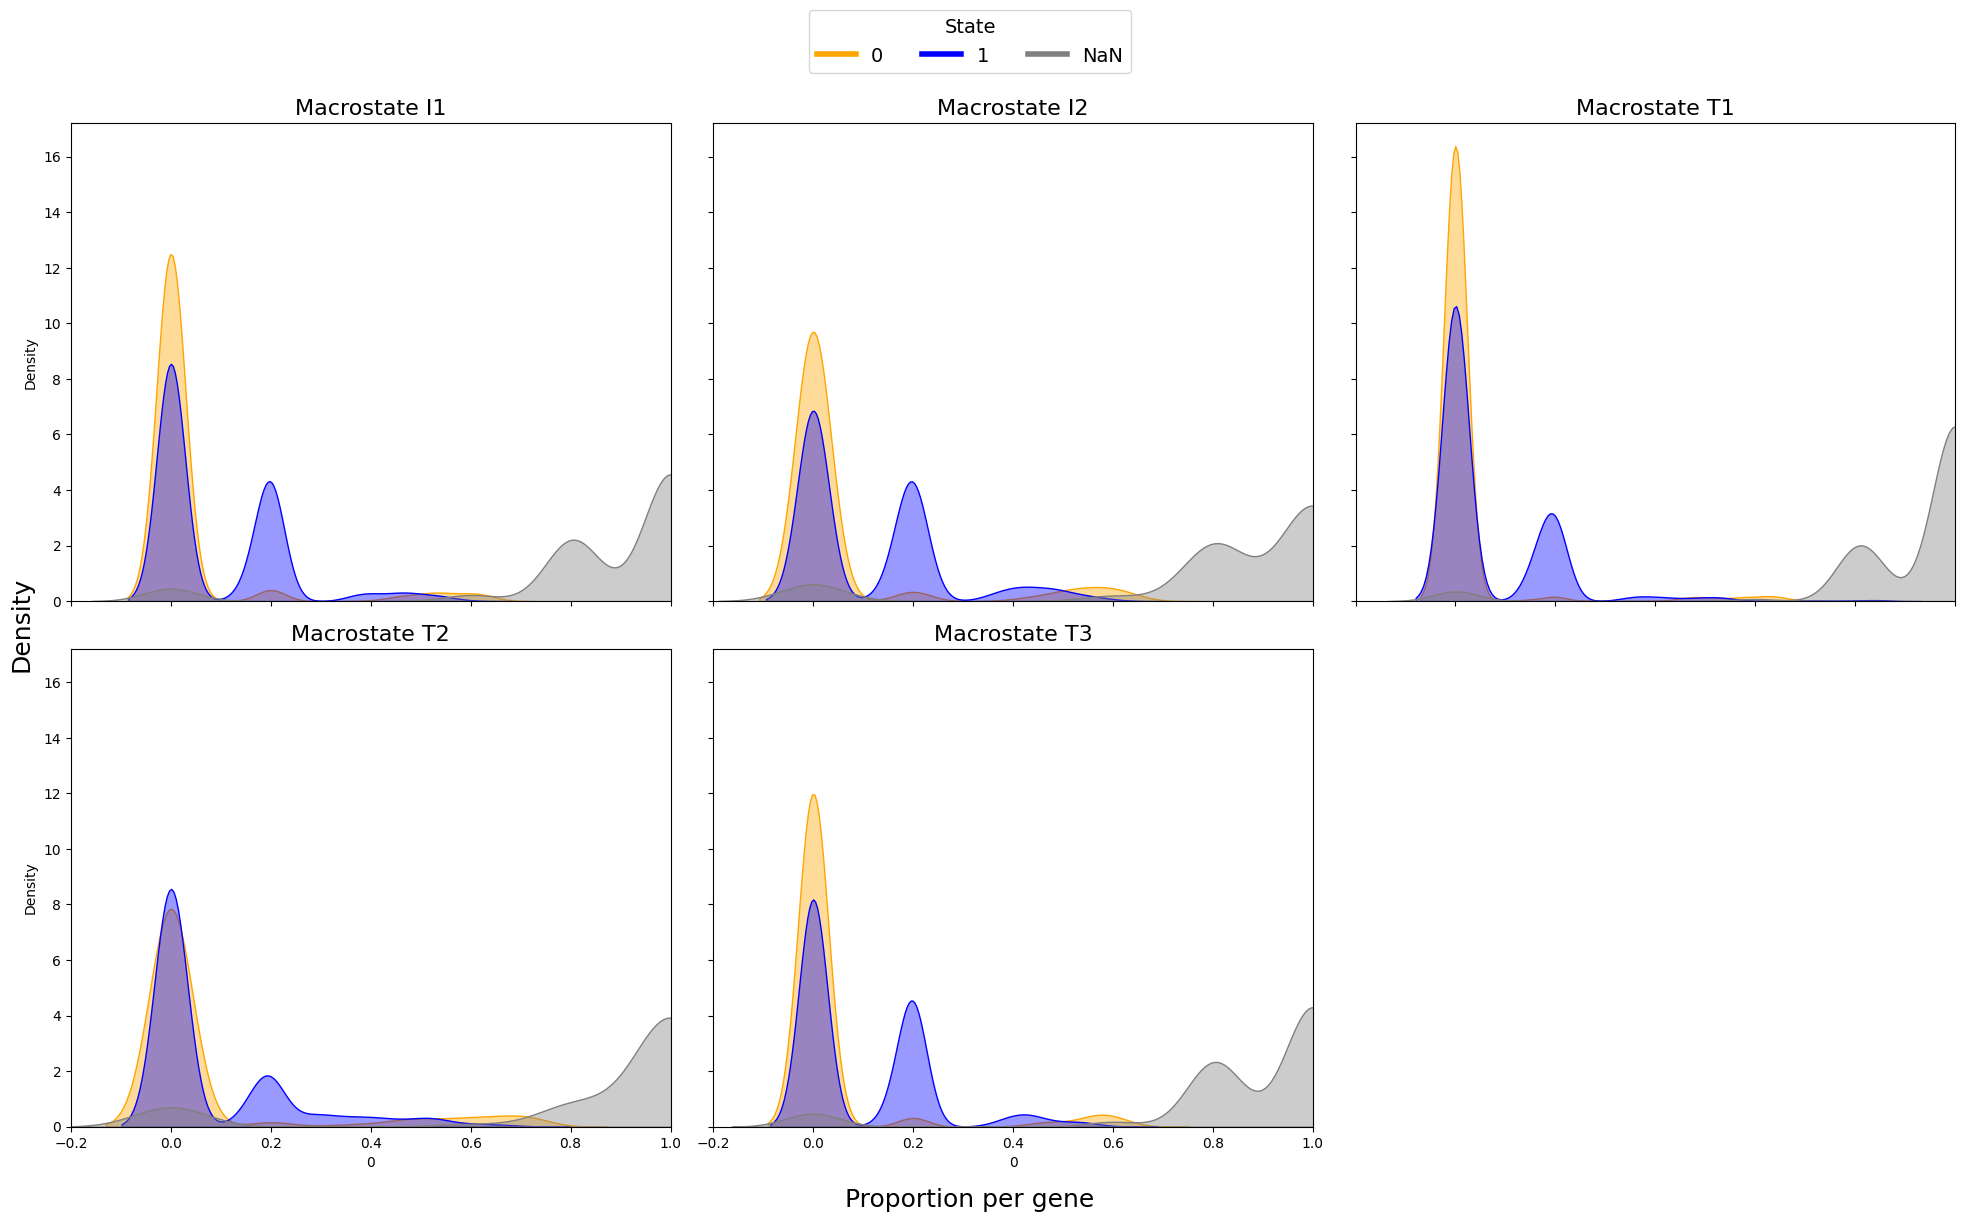

In [6]:
warnings.filterwarnings("ignore")
# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()

macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']

binarized_states = {}
adata_ct_dict = {}
deg_lists_up = {}
deg_lists_down = {}
enrich_results = {}
hvg_dict = {}
all_hvg = set()

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ct in enumerate(macrostates):

    print(f"\n{'='*50}")
    print(f"Processing {ct}...")

    ax = axes[i]

    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"{n_cells} cells")

    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index.tolist()
    hvg_dict[ct] = hvg_genes
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )
    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : scBoolSeq
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",
        margin_quantile=0.2,
        dor_threshold=0.85,
        alpha=0
    )

    scbool.fit(expr_df_full)
    binarized = scbool.binarize(expr_df_full)

    # STEP 4 : proportions per gene
    n_cells = len(binarized)

    gene_props = pd.DataFrame({
        "0": (binarized == 0).sum(axis=0) / n_cells,
        "1": (binarized == 1).sum(axis=0) / n_cells,
        "NaN": binarized.isna().sum(axis=0) / n_cells
    })

    # STEP 5 : plot
    sns.kdeplot(
        gene_props["0"],
        fill=True,
        alpha=0.4,
        color="orange",
        label="0",
        ax=ax
    )

    sns.kdeplot(
        gene_props["1"],
        fill=True,
        alpha=0.4,
        color="blue",
        label="1",
        ax=ax
    )

    sns.kdeplot(
        gene_props["NaN"],
        fill=True,
        alpha=0.4,
        color="gray",
        label="NaN",
        ax=ax
    )

    ax.set_title(f"Macrostate {ct}", fontsize=16)
    ax.set_xlim(-0.2, 1)

    if ax.get_legend():
        ax.get_legend().remove()

    del adata_ct, expr_df_full, scbool
    gc.collect()

fig.delaxes(axes[5])

# Axis
fig.supxlabel("Proportion per gene", fontsize=18)
fig.supylabel("Density", fontsize=18)

# Legende
handles = [
    plt.Line2D([0], [0], color="orange", lw=4),
    plt.Line2D([0], [0], color="blue", lw=4),
    plt.Line2D([0], [0], color="gray", lw=4)
]

labels = ["0", "1", "NaN"]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=14,
    title="State",
    title_fontsize=14,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    f"{output_directory}/distribution_scboolseq_all_macrostates.png",
    dpi=200,
    bbox_inches="tight")

plt.show()

In [7]:
warnings.filterwarnings("ignore")

# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()
macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']
binarized_states = {}
adata_ct_dict = {}
deg_lists_up = {}
deg_lists_down = {}
enrich_results = {}
thresholds_per_ct = {}
hvg_dict = {}
all_hvg = set()

def find_valley_thresholds(values, bandwidth=0.1, order=30):
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.array([])
    kde = gaussian_kde(values, bw_method=bandwidth)
    x = np.linspace(values.min(), values.max(), 1000)
    density = kde(x)
    minima_idx = argrelmin(density, order=order)[0]
    return x[minima_idx]

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")
    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"{n_cells} cells")

   # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index.tolist()
    hvg_dict[ct] = hvg_genes
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )
    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f"{expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : scBoolSeq
    scbool = scBoolSeq(zeroinf_binarizer="quantile", margin_quantile=0.2, dor_threshold=0.85, alpha=0)
    scbool.fit(expr_df_full)
    binarized = scbool.binarize(expr_df_full)

    # STEP 4 : Proportions per genes
    gene_stats = {}
    for gene in binarized.columns:
        col = binarized[gene]
        gene_stats[gene] = {
            "prop_1":   (col == 1).mean(),
            "prop_0":   (col == 0).mean(),
            "prop_nan": col.isna().mean()
        }
    stats_df = pd.DataFrame(gene_stats).T

    # STEP 5 : Thresholds by KDE valley
    t_on  = find_valley_thresholds(stats_df["prop_1"].values)
    t_off = find_valley_thresholds(stats_df["prop_0"].values)
    t_nan = find_valley_thresholds(stats_df["prop_nan"].values)

    thresholds_per_ct[ct] = {
        "t_on":  t_on,
        "t_off": t_off,
        "t_nan": t_nan
    }

    print(f"Thresholds ON  : {np.round(t_on,  3)}")
    print(f"Thresholds OFF : {np.round(t_off, 3)}")
    print(f"Thresholds NaN : {np.round(t_nan, 3)}")

    def majority_vote_adaptive(col, t_on, t_off, t_nan):
    # Prendre le dernier seuil (le plus discriminant)
        seuil_on  = t_on[-1]  if len(t_on)  > 0 else 0.5
        seuil_off = t_off[-1] if len(t_off) > 0 else 0.5
        seuil_nan = t_nan[-1] if len(t_nan) > 0 else 0.8

        prop_nan = col.isna().mean()
        prop_1   = (col == 1).mean()
        prop_0   = (col == 0).mean()

        if prop_nan > seuil_nan:
            return np.nan

        if prop_1 > seuil_on:
            return 1
        elif prop_0 > seuil_off:
            return 0
        else:
            return np.nan

    aggregated = binarized.apply(lambda col: majority_vote_adaptive(col, t_on, t_off, t_nan),axis=0)
    binarized_states[ct] = aggregated
    print(f"ON: {(aggregated == 1).sum()} | OFF: {(aggregated == 0).sum()} | NaN: {aggregated.isna().sum()}")

    del adata_ct, expr_df_full, scbool
    gc.collect()



Processing I1...
5018 cells
  2000 HVGs selected
2000 genes after removing all-zero
Thresholds ON  : [0.081 0.285 0.424 0.51 ]
Thresholds OFF : [0.103 0.304 0.489 0.575]
Thresholds NaN : [0.3   0.694 0.909]
ON: 28 | OFF: 42 | NaN: 1930

Processing I2...
1015 cells
  2000 HVGs selected
2000 genes after removing all-zero
Thresholds ON  : [0.082 0.278 0.453]
Thresholds OFF : [0.105 0.302 0.546]
Thresholds NaN : [0.301 0.69  0.905]
ON: 90 | OFF: 102 | NaN: 1808

Processing T1...
264 cells
  2000 HVGs selected
2000 genes after removing all-zero
Thresholds ON  : [0.08  0.271 0.456 0.503 0.619 0.674 0.758 0.806]
Thresholds OFF : [0.071 0.172 0.237 0.326 0.381 0.416 0.495 0.546 0.59 ]
Thresholds NaN : [0.185 0.437 0.693 0.914]
ON: 5 | OFF: 28 | NaN: 1967

Processing T2...
1797 cells
  2000 HVGs selected
2000 genes after removing all-zero
Thresholds ON  : [0.083 0.243 0.328 0.378 0.472 0.596]
Thresholds OFF : [0.108 0.263 0.532 0.62 ]
Thresholds NaN : [0.303 0.69  0.898]
ON: 20 | OFF: 111 | Na

Binarization basic count >=1 =1, count=0 =0


Processing I1...
  5018 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing I2...
  1015 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T1...
  264 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T2...
  1797 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done

Processing T3...
  1699 cells
  2000 HVGs selected
 2000 genes after removing all-zero
 2000 genes binarized
  Binarization done


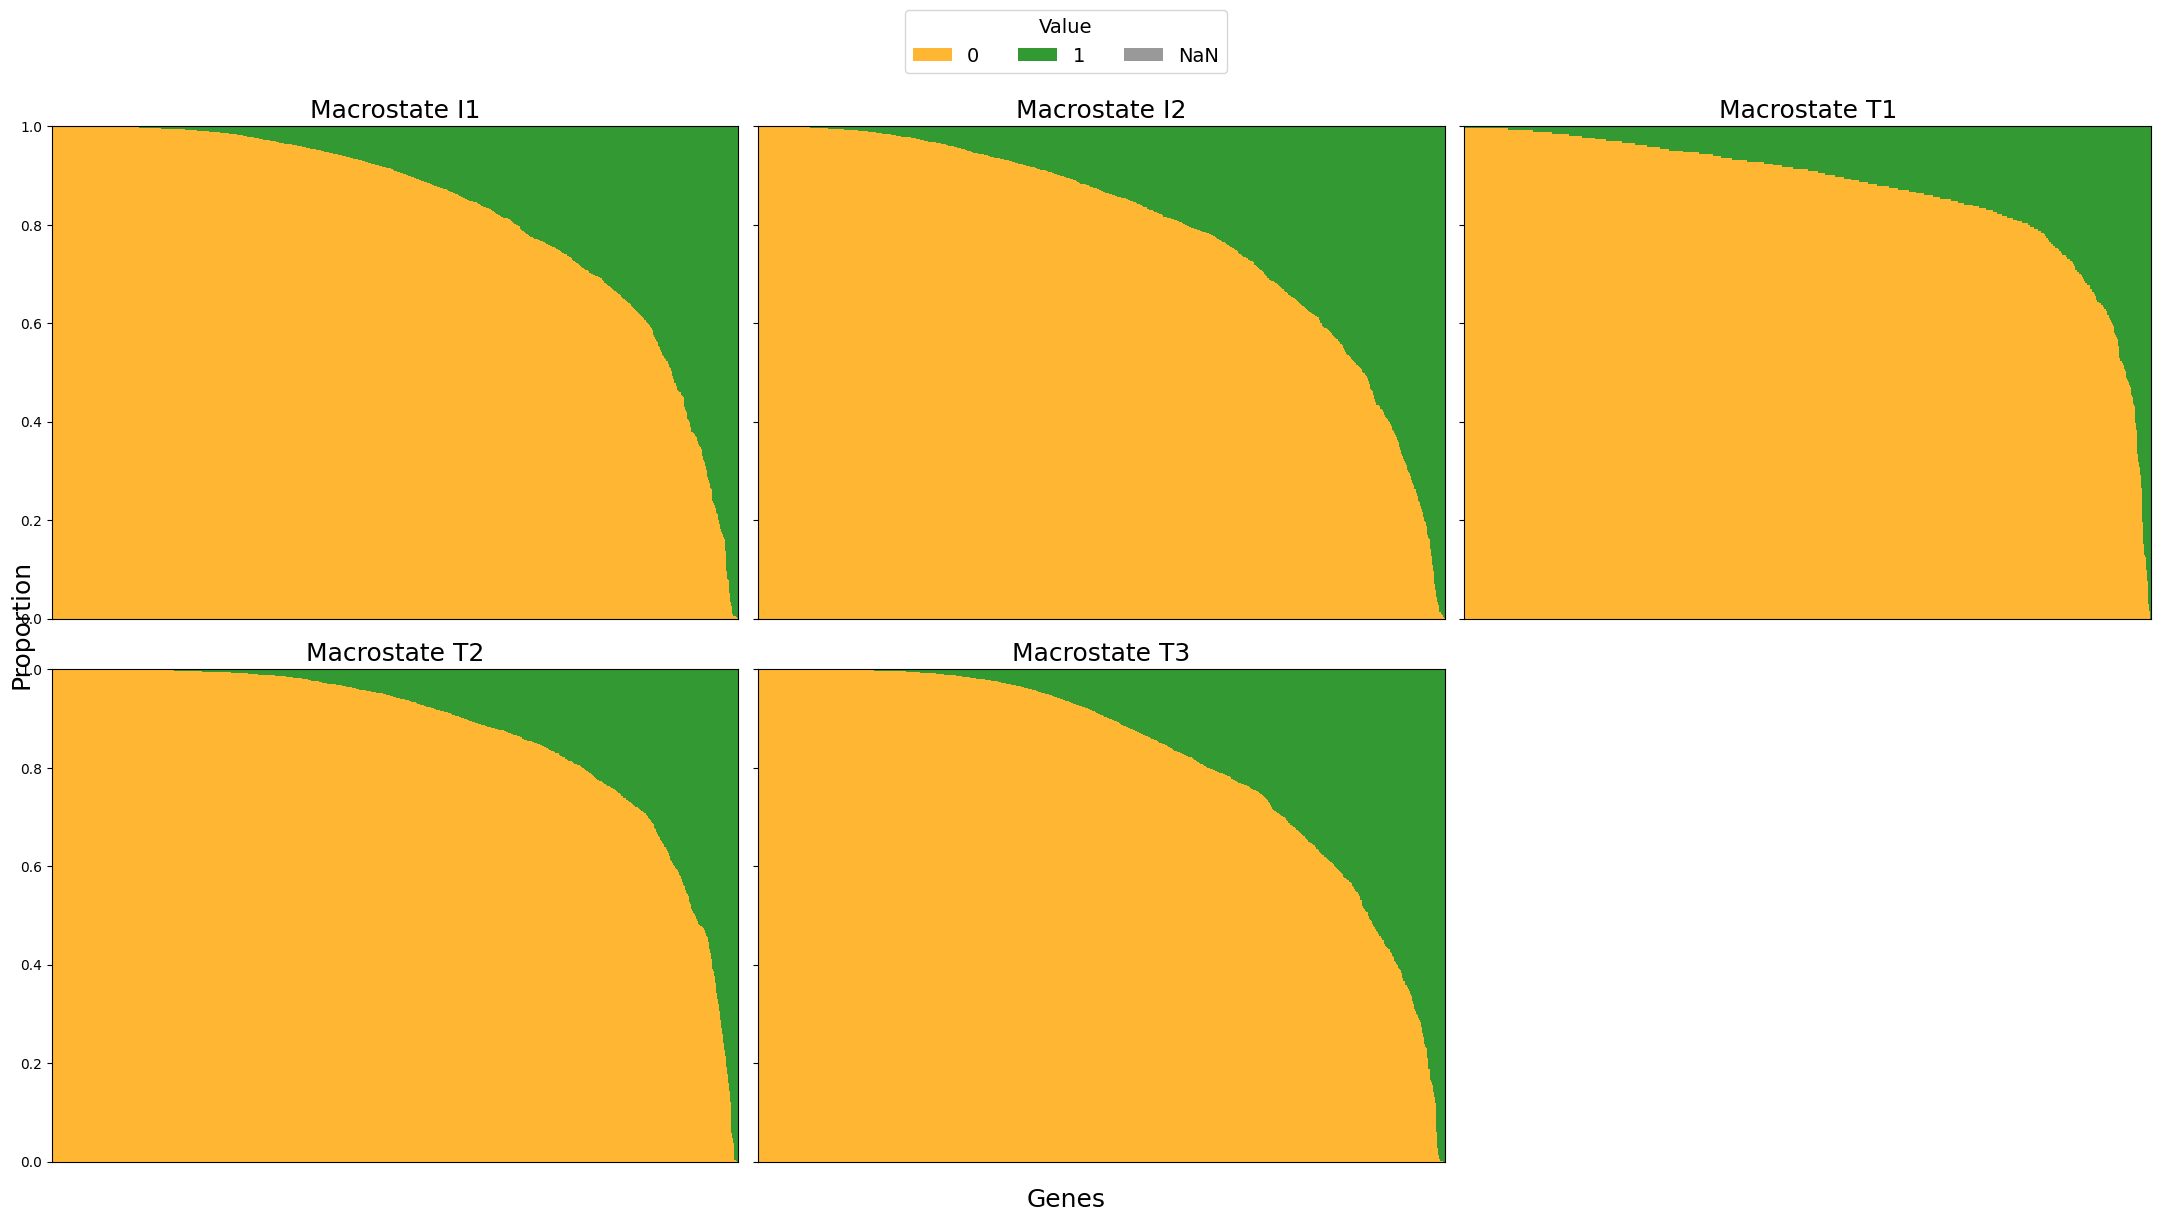

In [7]:
warnings.filterwarnings("ignore")

macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']

binarized_states = {}
all_hvg = set()
adata_ct_dict = {}

# One figure 
fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ct in enumerate(macrostates):
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")

    ax = axes[i]

    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")

    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index
    all_hvg.update(hvg_genes)

    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )

    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : Binarize per macrostate
    # Binairization with a threshold : ~0 UMI (log(1))
    threshold = np.log(1)
    binarized = (expr_df_full > threshold).astype(int)

    print(f" {binarized.shape[1]} genes binarized")
    print(f"  Binarization done")

    # STEP 4 : Plots
    n_cells = len(binarized)

    proportions = pd.DataFrame({
        '0': binarized.apply(lambda col: (col == 0.0).sum() / n_cells).values,
        '1': binarized.apply(lambda col: (col == 1.0).sum() / n_cells).values,
        'NaN': binarized.apply(lambda col: col.isna().sum() / n_cells).values
    })

    proportions = proportions.sort_values(
        ['0', '1'],
        ascending=[False, False]
    ).reset_index(drop=True)

    x = np.arange(len(proportions))

    ax.bar(x, proportions['0'], width=1.0, color='orange', alpha=0.8, label='0')
    ax.bar(x, proportions['1'], width=1.0, bottom=proportions['0'],
           color='green', alpha=0.8, label='1')
    ax.bar(x, proportions['NaN'], width=1.0,
           bottom=proportions['0'] + proportions['1'],
           color='gray', alpha=0.8, label='NaN')

    ax.set_xlim(-0.5, len(proportions) - 0.5)
    ax.margins(x=0)
    ax.set_title(f'Macrostate {ct}', fontsize=18)
    ax.set_xticks([])

    del adata_ct, expr_df_full
    gc.collect()

fig.delaxes(axes[5])

# Axis
fig.supxlabel("Genes", fontsize=18)
fig.supylabel("Proportion", fontsize=18)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles,labels,title="Value",loc="upper center",ncol=3,fontsize=14,title_fontsize=14,bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{output_directory}/proportions_basic_all_macrostates.png",dpi=200,bbox_inches="tight")
plt.show()